In [ ]:
import pathlib
import pandas as pd
import numpy as np

import random 
import tracemalloc
import time
import itertools
import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from pycytominer import normalize, feature_select, aggregate
from scipy.interpolate import griddata


In [2]:
def generate_synthetic_data(number_of_samples: int, number_of_features: int, feature_distribution: str, feature_value_range: tuple) -> pd.DataFrame:
    """
    generate synthetic profile data to test out on cytomining

    Parameters
    ----------
    number_of_samples : int
        Number of samples to generate(rows)
    number_of_features : int
        Number of features to generate(columns)
    feature_distribution : str
        Distribution of the features ("normal", "uniform", "bimodal")
    feature_value_range : tuple
        Range of values for the features (min, max)

    Returns
    -------
    pd.DataFrame
        Synthetic data frame with the specified dimensions and distributions

    Raises
    ------
    ValueError
        If the feature_distribution is not supported
    """
    if feature_distribution == "normal":
        data = np.random.normal(loc=0, scale=1, size=(number_of_samples, number_of_features))
    elif feature_distribution == "uniform":
        data = np.random.uniform(low=feature_value_range[0], high=feature_value_range[1], size=(number_of_samples, number_of_features))
    elif feature_distribution == "bimodal":
        data1 = np.random.normal(loc=-2, scale=1, size=(number_of_samples // 2, number_of_features))
        data2 = np.random.normal(loc=2, scale=1, size=(number_of_samples - number_of_samples // 2, number_of_features))
        data = np.vstack((data1, data2))
    else:
        raise ValueError(f"Unsupported feature distribution: {feature_distribution}")
    
    feature_min, feature_max = feature_value_range
    data = np.clip(data, feature_min, feature_max)
    
    # name the features as feature_1, feature_2, ..., feature_n
    feature_names = [f"feature_{i+1}" for i in range(number_of_features)]
    # add two metadata columns: "Metadata_well" and "Metadata_treatment"
    # make 10% of the samples Metadata_treatment == DMSO and the rest Metadata_treatment == compound
    # make Metadata_well as A01, A02, ..., P24 and repeat until the number of samples is reached
    metadata_well = [f"A{i:02d}" for i in range(1, 25)] * (number_of_samples // 24 + 1)
    metadata_treatment = ["DMSO"] * (number_of_samples // 10) + ["compound"] * (number_of_samples - number_of_samples // 10)
    metadata_df = pd.DataFrame({
        "Metadata_well": metadata_well[:number_of_samples],
        "Metadata_treatment": metadata_treatment[:number_of_samples]
    })
    return pd.concat([pd.DataFrame(data, columns=feature_names), metadata_df], axis=1)

def start_memory_and_time_profiling() -> float:
    """
    Start profiling the data

    Returns
    -------
    float
        start time
    """
    tracemalloc.start()
    start_time = time.perf_counter()
    return start_time

def stop_memory_and_time_profiling(start_time: float, process_name: str):
    """
    Retrieve the profiling 

    Parameters
    ----------
    start_time : float
        Start time
    process_name : str
        Process name to output

    Returns
    -------
    Tuple[float, int, int]
        Elapsed time, current memory usage, peak memory usage for the process
    """
    end_time = time.perf_counter()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    elapsed_time = end_time - start_time
    return elapsed_time, current, peak, process_name

def run_data_synthesis_through_data_run_with_profiling(
    **kwargs
)-> pd.DataFrame:
    """
    Run the data synthesis through a data run with profiling

    Parameters
    ----------
    **kwargs
        Keyword arguments for the data synthesis and data run

    Returns
    -------
    pd.DataFrame
        Data frame with the 
        profiling results for each step of the data synthesis and data run
    """
    number_of_samples = kwargs.get("number_of_samples")
    number_of_features = kwargs.get("number_of_features")
    feature_distribution = kwargs.get("feature_distribution")
    feature_value_range = kwargs.get("feature_value_range")
    # generate the synthetic data
    df = generate_synthetic_data(number_of_samples, number_of_features, feature_distribution, feature_value_range)
    # create a list to store the profiling results for each step of the data synthesis and data run
    profiling_results = []
    
    # normalize the data
    start_time = start_memory_and_time_profiling()
    normalized_df = normalize(
        df,
        samples="Metadata_treatment == 'DMSO'",
        features=[x for x in df.columns if "Metadata" not in x],
        method="standardize",
        meta_features=["Metadata_well", "Metadata_treatment"],
    )
    profiling_results.append((stop_memory_and_time_profiling(start_time, "normalize")))

    # feature select the data 
    start_time = start_memory_and_time_profiling()
    feature_selected_df = feature_select(
        normalized_df,
        features=[x for x in normalized_df.columns if "Metadata" not in x],
        operation="variance_threshold",
    )
    profiling_results.append((stop_memory_and_time_profiling(start_time, "feature_select")))

    # aggregate the data
    start_time = start_memory_and_time_profiling()
    aggregated_df = aggregate(
        feature_selected_df,
        strata=["Metadata_treatment", "Metadata_well"],
        features=[x for x in feature_selected_df.columns if "Metadata" not in x],
        operation="median",
    )
    profiling_results.append((stop_memory_and_time_profiling(start_time, "aggregate")))

    df = pd.DataFrame(profiling_results, columns=["elapsed_time", "current_memory_usage_B", "peak_memory_usage_B", "process_name"])
    df['current_memory_usage_MB'] = df['current_memory_usage_B'] / (1024 * 1024)
    df['peak_memory_usage_MB'] = df['peak_memory_usage_B'] / (1024 * 1024)
    df['current_memory_usage_GB'] = df['current_memory_usage_B'] / (1024 * 1024 * 1024)
    df['peak_memory_usage_GB'] = df['peak_memory_usage_B'] / (1024 * 1024 * 1024)
    df["number_of_samples"] = number_of_samples
    df["number_of_features"] = number_of_features
    df["feature_distribution"] = feature_distribution
    df["feature_value_range"] = str(feature_value_range)
    df['matrix_size'] = number_of_samples * number_of_features
    return df

In [3]:
path_to_results = pathlib.Path("profiling_results.parquet")
individual_results_path = pathlib.Path("results/")
individual_results_path.mkdir(exist_ok=True, parents=True)

In [4]:
number_of_samples_search_space = [100, 1_000, 10_000, 100_000]
number_of_features_search_space = [10, 100, 1_000,]
feature_distribution_search_space = ["normal"]
feature_value_ranges_potential = [(0, 1)]

# get all combinations of the search space
search_space_combinations = list(itertools.product(number_of_samples_search_space, number_of_features_search_space, feature_distribution_search_space, feature_value_ranges_potential))

In [5]:
if path_to_results.exists():
    df = pd.read_parquet(path_to_results)
else:
    combinations_results = []
    for combination in tqdm.tqdm(search_space_combinations, desc="Running data synthesis through data run with profiling for all combinations", total=len(search_space_combinations)):
        number_of_samples, number_of_features, feature_distribution, feature_value_range = combination
        individual_result_path = individual_results_path / f"result_nsamples_{number_of_samples}_nfeatures_{number_of_features}_dist_{feature_distribution}_range_{feature_value_range[0]}_{feature_value_range[1]}.parquet"
        if individual_result_path.exists():
            df = pd.read_parquet(individual_result_path)
            combinations_results.append(df)
        else:
            df = run_data_synthesis_through_data_run_with_profiling(
                number_of_samples=number_of_samples,
                number_of_features=number_of_features,
                feature_distribution=feature_distribution,
                feature_value_range=feature_value_range
            )
            df.to_parquet(individual_result_path)
            combinations_results.append(df)

    df = pd.concat(combinations_results, ignore_index=True)
    df.to_parquet(path_to_results)

Running data synthesis through data run with profiling for all combinations: 100%|██████████| 12/12 [00:00<00:00, 180.50it/s]


In [13]:
df.tail()

,elapsed_time,current_memory_usage_B,peak_memory_usage_B,process_name,current_memory_usage_MB,peak_memory_usage_MB,current_memory_usage_GB,peak_memory_usage_GB,number_of_samples,number_of_features,feature_distribution,feature_value_range,matrix_size
31,0.350915,39271,3485769,feature_select,0.037452,3.324288,0.000037,0.003246,100000,100,normal,"(0, 1)",10000000
32,0.109424,62730,83294312,aggregate,0.059824,79.435646,0.000058,0.077574,100000,100,normal,"(0, 1)",10000000
33,0.526599,800932216,1601315116,normalize,763.828484,1527.133099,0.745926,1.491341,100000,1000,normal,"(0, 1)",100000000
34,3.817075,123782,3807315,feature_select,0.118048,3.630939,0.000115,0.003546,100000,1000,normal,"(0, 1)",100000000
35,1.055177,527447,803911099,aggregate,0.503013,766.669368,0.000491,0.748701,100000,1000,normal,"(0, 1)",100000000


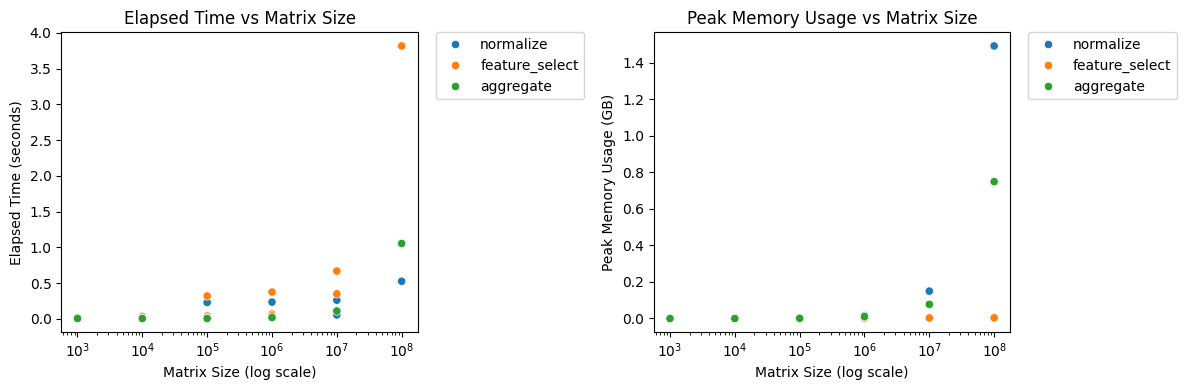

In [7]:
# plot the results
# show the time and memory usage for each process as a function of the number of samples and number of features, colored by the feature distribution and shaped by the feature value range

plt.figure(figsize=(12, 4))
plt.subplot(121)
sns.scatterplot(
    data=df,
    x="matrix_size",
    y="elapsed_time",
    hue="process_name",
    sizes=(20, 2000)
)
plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Matrix Size (log scale)")
plt.ylabel("Elapsed Time (seconds)")
plt.title("Elapsed Time vs Matrix Size")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.subplot(122)
sns.scatterplot(
    data=df,
    x="matrix_size",
    y="peak_memory_usage_GB",
    hue="process_name",
    sizes=(20, 2000)
)
plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Matrix Size (log scale)")
plt.ylabel("Peak Memory Usage (GB)")
plt.title("Peak Memory Usage vs Matrix Size")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()

In [22]:
# given sample number and feature number 
# interpolate the time and memory usage for each process 
# do the interpolation at the intersection of the sample number and feature number
# which is different than matrix size 
# as the code treats rows and columns differently

def get_interpolated_time_and_memory_usage(df, new_sample_number, new_feature_number):
    interpolated_results = []
    for process in processes:
        subset = df[df["process_name"] == process]
        points = subset[["number_of_samples", "number_of_features"]].values
        elapsed_time = subset["elapsed_time"].values
        peak_memory = subset["peak_memory_usage_GB"].values
        # interpolate if within the bounds of the data
        # otherwise extrapolate but with a warning
        if (new_sample_number < points[:, 0].min() or new_sample_number > points[:, 0].max() or
            new_feature_number < points[:, 1].min() or new_feature_number > points[:, 1].max()):
            print(f"Warning: Extrapolating for process {process} at sample number {new_sample_number} and feature number {new_feature_number}")
            # extrapolate by fittint the curve and then predicting the value at the new sample number and feature number
            # fit a linear regression model to the data
            from sklearn.linear_model import LinearRegression
            model_time = LinearRegression()
            model_memory = LinearRegression()
            model_time.fit(points, elapsed_time)
            model_memory.fit(points, peak_memory)
            # predict the value at the new sample number and feature number
            interpolated_time = model_time.predict([[new_sample_number, new_feature_number]])[0]
            interpolated_memory = model_memory.predict([[new_sample_number, new_feature_number]])[0]
        else:
            interpolated_time = np.round(griddata(points, elapsed_time, (new_sample_number, new_feature_number), method="linear"), 2)
            interpolated_memory = np.round(griddata(points, peak_memory, (new_sample_number, new_feature_number), method="linear"), 2)
        interpolated_results.append({
            "process_name": process,
            "interpolated_time": interpolated_time,
            "interpolated_memory": interpolated_memory,
            "number_of_samples": new_sample_number,
            "number_of_features": new_feature_number,
            "matrix_size": new_sample_number * new_feature_number
        })
    interpolated_df = pd.DataFrame(interpolated_results)
    return interpolated_df

get_interpolated_time_and_memory_usage(df, 500_000, 50_000)

,process_name,interpolated_time,interpolated_memory,number_of_samples,number_of_features,matrix_size
0,normalize,15.643477,23.323323,500000,50000,25000000000
1,feature_select,70.827867,0.041429,500000,50000,25000000000
2,aggregate,16.808310,11.694397,500000,50000,25000000000
